In [1]:
!pip -q install pandas numpy scikit-learn matplotlib umap-learn

In [2]:
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()
input_file = next(iter(uploaded))

df = pd.read_csv(input_file, low_memory=False)

df["sequence"] = (
    df["sequence"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Rows:", len(df))
print("Unique:", df["sequence"].nunique())

assert len(df) == 60000
assert df["sequence"].nunique() == 60000

Saving STEP10_60K_WITH_PEPSYSCO_SYNTHESIZABILITY.csv to STEP10_60K_WITH_PEPSYSCO_SYNTHESIZABILITY.csv
Rows: 60000
Unique: 60000


In [3]:
uploaded = files.upload()
embedding_file = next(iter(uploaded))

data = np.load(
    embedding_file,
    allow_pickle=True
)

embeddings = data["embeddings"]
embedding_sequences = data["sequence"].astype(str)

print("Embedding shape:", embeddings.shape)
print("Sequences:", len(embedding_sequences))

assert embeddings.shape == (60000, 480)
assert len(embedding_sequences) == 60000

Saving STEP9_ESM2_35M_EMBEDDINGS_60K.npz to STEP9_ESM2_35M_EMBEDDINGS_60K.npz
Embedding shape: (60000, 480)
Sequences: 60000


In [4]:
same_order = np.array_equal(
    df["sequence"].to_numpy(),
    embedding_sequences
)

print("Exact sequence/order match:", same_order)

if not same_order:
    raise RuntimeError(
        "CSV and embedding sequence order do not match."
    )

Exact sequence/order match: True


In [5]:
from sklearn.preprocessing import normalize

X = embeddings.astype(np.float32)

X_norm = normalize(X)

print("Shape:", X_norm.shape)

norms = np.linalg.norm(X_norm, axis=1)

print(
    "Normalized norms:",
    norms.min(),
    norms.mean(),
    norms.max()
)

Shape: (60000, 480)
Normalized norms: 0.9999994 1.0 1.0000004


In [6]:
from sklearn.neighbors import NearestNeighbors
import time

t0 = time.time()

nn = NearestNeighbors(
    n_neighbors=6,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1
)

nn.fit(X_norm)

distances, indices = nn.kneighbors(X_norm)

print(
    "Finished in",
    round((time.time() - t0) / 60, 2),
    "min"
)

Finished in 2.61 min


In [7]:
df["embedding_nn1_cosine_similarity"] = (
    1.0 - distances[:, 1]
)

df["embedding_nn5_mean_cosine_similarity"] = (
    1.0 - distances[:, 1:6]
).mean(axis=1)

df["embedding_nn1_index"] = indices[:, 1]

df["embedding_nn1_sequence"] = (
    df.iloc[indices[:, 1]]["sequence"].to_numpy()
)

print(
    df[
        [
            "sequence",
            "embedding_nn1_sequence",
            "embedding_nn1_cosine_similarity",
            "embedding_nn5_mean_cosine_similarity"
        ]
    ].head()
)

                    sequence     embedding_nn1_sequence  \
0   IWEELLRKKLLAAAKWKMMAWWWW         VALELWKKWWKKLAAMMW   
1  FLLEELLLKWAMAAAKWWKLRWWWW     CAKEEAAKWWKWKLLLLRWLWW   
2      GAFGAIKLIWKSLKWWWWWWW      VWGGLIAALKWWWKWWWKKWI   
3      LHYRIILMRLAKWWWWWWWWW        PRLVCYYRAMKWWWWWWWW   
4  FIHIKIIKNNALLLKKWWWWWWWWW  LFWNLKNKTLKIYYRKWWWWWWWWW   

   embedding_nn1_cosine_similarity  embedding_nn5_mean_cosine_similarity  
0                         0.993707                              0.992652  
1                         0.989101                              0.987589  
2                         0.983066                              0.981622  
3                         0.989317                              0.988187  
4                         0.983162                              0.979332  


In [8]:
div_cols = [
    "embedding_nn1_cosine_similarity",
    "embedding_nn5_mean_cosine_similarity"
]

print(
    df[div_cols].describe(
        percentiles=[
            0.05,
            0.25,
            0.50,
            0.75,
            0.95
        ]
    )
)

       embedding_nn1_cosine_similarity  embedding_nn5_mean_cosine_similarity
count                     60000.000000                          60000.000000
mean                          0.988624                              0.986745
std                           0.004550                              0.005060
min                           0.924291                              0.906332
5%                            0.980515                              0.977738
25%                           0.986834                              0.984841
50%                           0.989488                              0.987763
75%                           0.991520                              0.989957
95%                           0.993803                              0.992332
max                           0.999947                              0.998124


In [9]:
import umap

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(X_norm)

df["umap_1"] = embedding_2d[:, 0]
df["umap_2"] = embedding_2d[:, 1]

print("UMAP shape:", embedding_2d.shape)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (60000, 2)


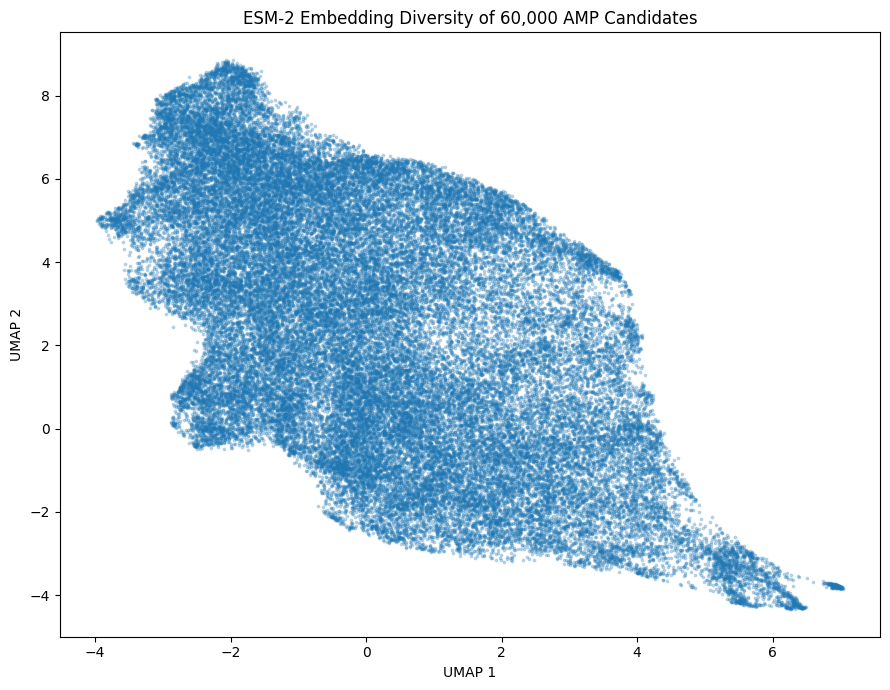

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    df["umap_1"],
    df["umap_2"],
    s=3,
    alpha=0.25
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("ESM-2 Embedding Diversity of 60,000 AMP Candidates")

plt.tight_layout()

plt.savefig(
    "/content/STEP11_UMAP_60K.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

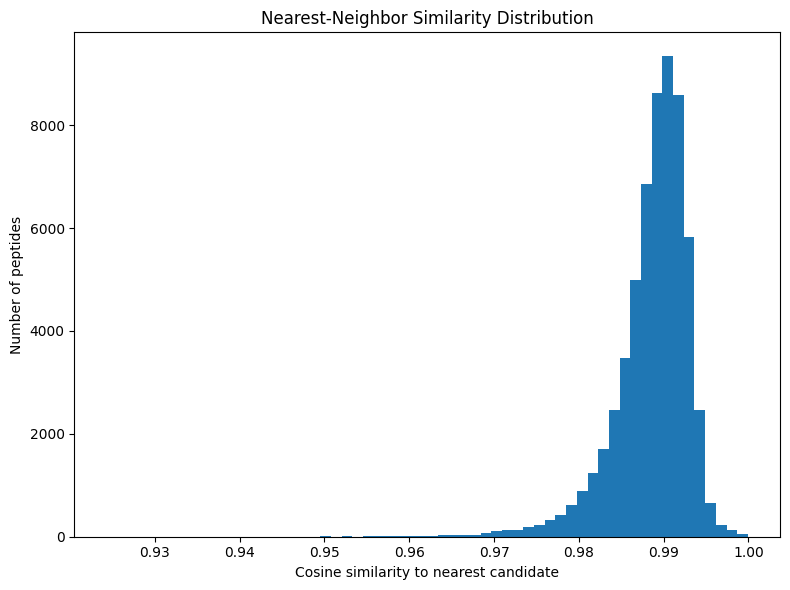

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.hist(
    df["embedding_nn1_cosine_similarity"],
    bins=60
)

plt.xlabel("Cosine similarity to nearest candidate")
plt.ylabel("Number of peptides")
plt.title("Nearest-Neighbor Similarity Distribution")

plt.tight_layout()

plt.savefig(
    "/content/STEP11_NEAREST_NEIGHBOR_SIMILARITY.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
!pip -q install hdbscan

In [13]:
import hdbscan
import numpy as np

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean"
)

labels = clusterer.fit_predict(
    embedding_2d
)

df["diversity_cluster"] = labels

n_clusters = len(set(labels) - {-1})
noise = int(np.sum(labels == -1))

print("Clusters:", n_clusters)
print("Noise points:", noise)
print("Noise fraction:", noise / len(df))

Clusters: 2
Noise points: 7
Noise fraction: 0.00011666666666666667


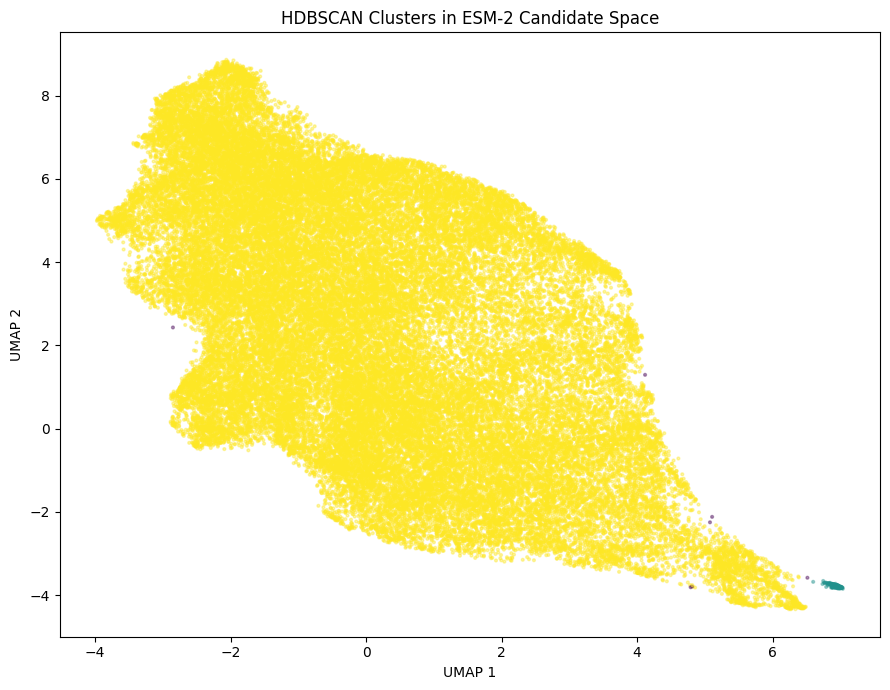

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.scatter(
    df["umap_1"],
    df["umap_2"],
    c=df["diversity_cluster"],
    s=4,
    alpha=0.4
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("HDBSCAN Clusters in ESM-2 Candidate Space")

plt.tight_layout()

plt.savefig(
    "/content/STEP11_UMAP_HDBSCAN_CLUSTERS.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
print("=" * 70)
print("STEP 11 VALIDATION")
print("=" * 70)

print("Rows:", len(df))
print("Unique sequences:", df["sequence"].nunique())

print("\nNearest-neighbor similarity:")
print(
    df["embedding_nn1_cosine_similarity"].describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    )
)

print("\nMean Top-5 neighbor similarity:")
print(
    df["embedding_nn5_mean_cosine_similarity"].describe(
        percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
    )
)

print("\nClusters:", n_clusters)
print("Noise:", noise)
print("Noise fraction:", noise / len(df))

print("\nCluster sizes:")
print(
    df["diversity_cluster"]
    .value_counts()
)

STEP 11 VALIDATION
Rows: 60000
Unique sequences: 60000

Nearest-neighbor similarity:
count    60000.000000
mean         0.988624
std          0.004550
min          0.924291
5%           0.980515
25%          0.986834
50%          0.989488
75%          0.991520
95%          0.993803
max          0.999947
Name: embedding_nn1_cosine_similarity, dtype: float64

Mean Top-5 neighbor similarity:
count    60000.000000
mean         0.986745
std          0.005060
min          0.906332
5%           0.977738
25%          0.984841
50%          0.987763
75%          0.989957
95%          0.992332
max          0.998124
Name: embedding_nn5_mean_cosine_similarity, dtype: float64

Clusters: 2
Noise: 7
Noise fraction: 0.00011666666666666667

Cluster sizes:
diversity_cluster
 1    59862
 0      131
-1        7
Name: count, dtype: int64


In [16]:
OUT = "/content/STEP11_60K_WITH_DIVERSITY_DIAGNOSTICS.csv"

df.to_csv(
    OUT,
    index=False
)

print("Saved:", OUT)

Saved: /content/STEP11_60K_WITH_DIVERSITY_DIAGNOSTICS.csv
